# Data Exploration with Seaborn and Plotly in Streamlit

### This notebook demonstrates how to use seaborn and plotly to get an understanding of a groundwater contamination dataset. 
- The goal is to create a Streamlit view for interactive data exploration.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import streamlit as st

In [2]:
%pwd

'c:\\Projects\\my_git_pages_website\\Py-and-Sky-Labs\\content\\Python Examples'

In [3]:

# Load data (adapt path as needed)
file_path = r"C:/Projects/my_git_pages_website/Py-and-Sky-Labs/content/Python Examples/Data/atlas_contamination_wells_result_sum_CTU_JOIN.csv"

# df = pd.read_csv('your_data.csv')
df = pd.read_csv(file_path)

# st.write('## Data Overview')
# st.write(df.head())
# st.write(df.describe())

### Check availiable fields

In [23]:
print(df.columns)


Index(['Join_Count', 'TARGET_FID', 'facility_c', 'facility_i', 'facility_t',
       'facility_n', 'sys_loc_co', 'loc_name', 'loc_type', 'loc_type_2',
       'well_statu', 'geologic_u', 'depth_of_w', 'bottom_of_', 'surf_elev',
       'latest_sam', 'number_of_', 'result_cou', 'non_detect', 'detect_bel',
       'exceedance', 'exceedan_1', 'exceedan_2', 'exceedan_3', 'exceedan_4',
       'exceedan_5', 'exceedan_6', 'detect_b_1', 'detect_b_2', 'detect_b_3',
       'detect_b_4', 'detect_b_5', 'latitude', 'longitude', 'eda_url',
       'data_downl', 'GNIS_FEATU', 'FEATURE_NA', 'CTU_CLASS', 'COUNTY_GNI',
       'COUNTY_COD', 'COUNTY_NAM', 'POPULATION', 'SHAPE_Leng',
       'Combined_GNIS_IDs', 'JoinKey'],
      dtype='object')


# Data Overview
#### This section provides a first look at the dataset, including its structure, definition and sources for field data. Understanding the columns and their types is essential for planning further analysis and identifying potential data quality issues.

### Metadata for Minnnesota GroundWater Contamination Atlas Summary data
| cleanup_well_result_sum Field Name | Definition                                                                                                      | Definition Source |
| ---------------------------------- | --------------------------------------------------------------------------------------------------------------- | ----------------- |
| OBJECTID                           | Esri record identifier                                                                                          | ESRI              |
| facility_code                      | EQuIS facility code                                                                                             | MPCA              |
| facility_id                        | EQuIS facility unique row ID                                                                                    | MPCA              |
| facility_type                      | Type of MPCA program for this site                                                                              | MPCA              |
| facility_name                      | EQuIS facility name                                                                                             | MPCA              |
| sys_loc_code                       | Well unique identifier in EQuIS                                                                                 | MPCA              |
| loc_name                           | Common name of the monitoring location                                                                          | MPCA              |
| loc_type                           | Type of monitoring location                                                                                     | MPCA              |
| loc_type_2                         | Additional details on the category of the location                                                              | MPCA              |
| well_status                        | If the monitoring location is active or was historically there but no longer present                            | MPCA              |
| geologic_unit_desc                 | Geological unit from which the well is drawing water (Aquifer code is comparable in Minnesota Well Index)       | MPCA              |
| depth_of_well                      | Depth below ground surface fo the well bottom, in feet                                                          | MPCA              |
| bottom_of_well_elev                | Elevation above sea level of the bottom of the well                                                             | MPCA              |
| surf_elev                          | Elevation of the ground surface at the monitoring location                                                      | MPCA              |
| latest_sampling_date               | Most recent date of a sampling event                                                                            | MPCA              |
| number_of_observations             | Number of sampling date events (count of days a sample was collected)                                           | MPCA              |
| result_count                       | Number of results (count of every lab result)                                                                   | MPCA              |
| non_detect_count                   | For the most recent observation, number of results with non detection of the analyte                            | MPCA              |
| detect_below_count                 | For the most recent observation, number of results with a detection of the analyte                              | MPCA              |
| exceedance_count                   | For the most recent observation, number of exceedances for any analyte with a health based guidance value (HBG) | MPCA              |
| exceedance_pct_max                 | Percent by which the HBG was exceeded. For instance, some sites may have a higher magnitude of exceedance       | MPCA              |
| exceedance_date_max                | Date of highest level of exceedance                                                                             | MPCA              |
| exceedance_cas_rn_list             | For the most recent observation, list of all CAS IDs with exceedances                                           | MPCA              |




In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17443 entries, 0 to 17442
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Join_Count         17443 non-null  int64  
 1   TARGET_FID         17443 non-null  int64  
 2   facility_c         17443 non-null  object 
 3   facility_i         17443 non-null  float64
 4   facility_t         17443 non-null  object 
 5   facility_n         17443 non-null  object 
 6   sys_loc_co         17443 non-null  object 
 7   loc_name           17443 non-null  object 
 8   loc_type           17443 non-null  object 
 9   loc_type_2         17443 non-null  object 
 10  well_statu         17443 non-null  object 
 11  geologic_u         17443 non-null  object 
 12  depth_of_w         17443 non-null  float64
 13  bottom_of_         17443 non-null  float64
 14  surf_elev          17443 non-null  object 
 15  latest_sam         17443 non-null  object 
 16  number_of_         174

In [24]:
df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']].head(20) 

,depth_of_w,bottom_of_,surf_elev,exceedance
0,0.0,0.0,,0.0
1,39.0,1347.0,1386.125,0.0
2,15.0,1270.0,1285,0.0
3,21.0,875.0,896,3.0
4,0.0,0.0,,0.0
5,0.0,0.0,,0.0
6,65.0,0.0,,0.0
7,32.2,70.0,102.37,0.0
8,80.0,1225.0,1304.7,0.0
9,260.0,0.0,,0.0


In [26]:
df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']].info()
df["surf_elev"] = pd.to_numeric(df["surf_elev"],errors='coerce')
df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17443 entries, 0 to 17442
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth_of_w  17443 non-null  float64
 1   bottom_of_  17443 non-null  float64
 2   surf_elev   17443 non-null  object 
 3   exceedance  17443 non-null  float64
dtypes: float64(3), object(1)
memory usage: 545.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17443 entries, 0 to 17442
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth_of_w  17443 non-null  float64
 1   bottom_of_  17443 non-null  float64
 2   surf_elev   12057 non-null  float64
 3   exceedance  17443 non-null  float64
dtypes: float64(4)
memory usage: 545.2 KB


## Univariate Analysis with Seaborn

Visualize the distribution of key variables to understand their spread and detect outliers.

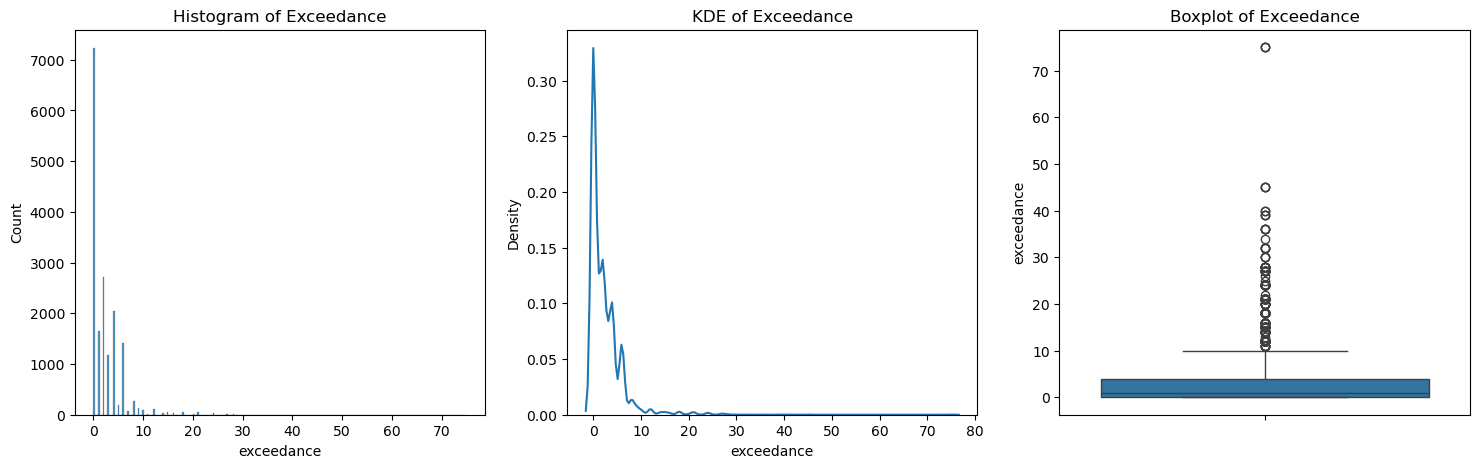

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['exceedance'], ax=axes[0], kde=False)
axes[0].set_title('Histogram of Exceedance')
sns.kdeplot(df['exceedance'], ax=axes[1])
axes[1].set_title('KDE of Exceedance')
sns.boxplot(y=df['exceedance'], ax=axes[2])
axes[2].set_title('Boxplot of Exceedance')

plt.show()


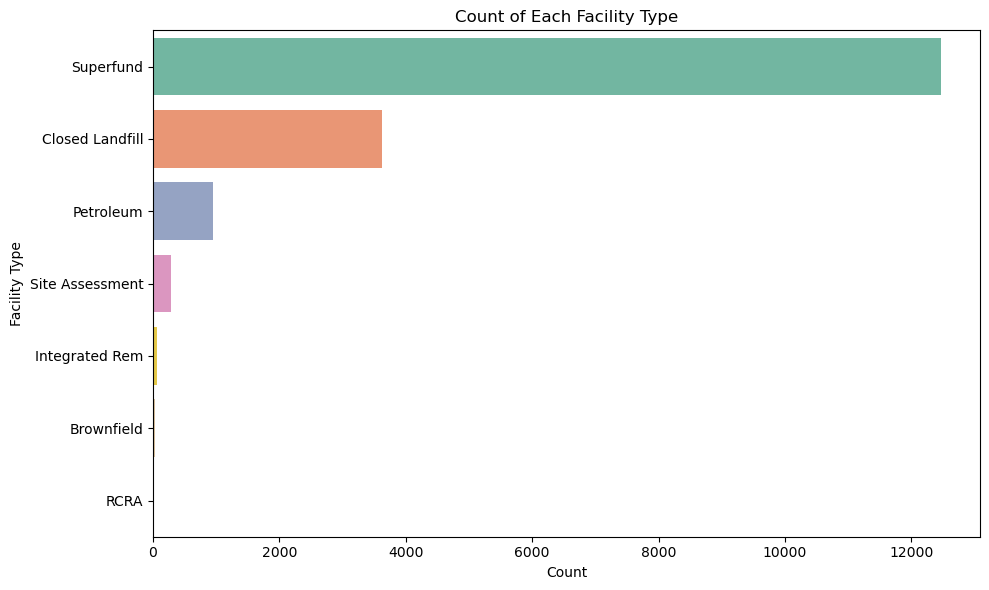

In [28]:
# Bar plot: count of each facility type, colored by type
plt.figure(figsize=(10,6))
sns.countplot(y='facility_t', data=df, palette='Set2',hue='facility_t', order=df['facility_t'].value_counts().index)
plt.title('Count of Each Facility Type')
plt.xlabel('Count')
plt.ylabel('Facility Type')
plt.tight_layout()
plt.show()

## Facility Types in Minnesota Contamination Altas
### Superfund Sites
These are sites governed by Minnesota's Environmental Response and Liability Act (MERLA), also known as Minnesota's Superfund Law. Superfund operates as a "polluter pays" system that requires investigation and cleanup of sites where hazardous substances, pollutants, or contaminants pose risks to human health and the environment. These sites may need investigation and cleanup, have cleanup underway, or have completed cleanup with ongoing long-term monitoring.
### Closed Landfill Sites
These represent Minnesota's Closed Landfill Program (CLP), which manages up to 114 closed, state-permitted mixed municipal solid waste landfills. The CLP is unique as the first program in the nation providing an alternative to EPA's Superfund program specifically for closed landfills. The program monitors environmental impacts, determines risks to public health and safety, and implements response actions to reduce site risks

### Other Facility Types
- Petroleum: Petroleum remediation sites dealing with fuel contamination

- Site Assessment: Sites undergoing environmental assessment processes

- Integrated Rem: Sites with integrated remediation approaches

- Brownfield: Contaminated properties where redevelopment is complicated by environmental issues

- RCRA: Sites regulated under the Resource Conservation and Recovery Act for hazardous waste management

In [ ]:
### Get category counts
counts = df["facility_t"].value_counts()
percents = df["facility_t"].value_counts(normalize=True)*100
facility_type_summary  = pd.DataFrame({"count":counts, "percentage":percents})
facility_type_summary

,count,percentage
facility_t,,
Superfund,12464,71.455598
Closed Landfill,3627,20.793441
Petroleum,952,5.457777
Site Assessment,288,1.651092
Integrated Rem,58,0.332512
Brownfield,32,0.183455
RCRA,22,0.126125


In [ ]:
### Summary statistics
df["facility_t"].describe()

count         17443
unique            7
top       Superfund
freq          12464
Name: facility_t, dtype: object

In [41]:
def colSummary(df, column):
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True)*100
    column_summary =  pd.DataFrame({'Count':counts, 'Percentages':percentages})
    return column_summary
 


In [43]:
colSummary(df,["facility_t"])

,Count,Percentages
facility_t,,
Superfund,12464,71.455598
Closed Landfill,3627,20.793441
Petroleum,952,5.457777
Site Assessment,288,1.651092
Integrated Rem,58,0.332512
Brownfield,32,0.183455
RCRA,22,0.126125


In [ ]:
### Check on facility type 
facility_type= "Brownfield"

brownfield_sites = df.loc[df["facility_t"]==facility_type]
print(f"{len(brownfield_sites)} Records")
brownfield_sites.head(5)

32 Records


,Join_Count,TARGET_FID,facility_c,facility_i,facility_t,facility_n,sys_loc_co,loc_name,loc_type,loc_type_2,...,GNIS_FEATU,FEATURE_NA,CTU_CLASS,COUNTY_GNI,COUNTY_COD,COUNTY_NAM,POPULATION,SHAPE_Leng,Combined_GNIS_IDs,JoinKey
380,1,381,BF0001290,101883512.0,Brownfield,CR 9 Truck Stop,2001005304,CS-SB-GP-07,Well,Well-Temporary,...,2395687.0,Lester Prairie,CITY,659491.0,43.0,McLeod,1945.0,15221.058487,2395687_659491,2001005304_2395687_659491
459,1,460,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007348,GP-10,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007348_2396500_659472
479,1,480,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007339,GP-01,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007339_2396500_659472
1272,1,1273,BF0001339,95842775.0,Brownfield,Avana on Seven,2001007775,PP-7,Well,Well,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007775_2396500_659472
1356,1,1357,BF0001290,101883512.0,Brownfield,CR 9 Truck Stop,2001005305,CS-SB-GP-08,Well,Well-Temporary,...,2395687.0,Lester Prairie,CITY,659491.0,43.0,McLeod,1945.0,15221.058487,2395687_659491,2001005305_2395687_659491


In [54]:
### Check sites by county
county ="Hennepin"
brownfield_sites_hennepin = brownfield_sites.loc[brownfield_sites["COUNTY_NAM"]==county]
print(f"{len(brownfield_sites_hennepin)} or {len(brownfield_sites_hennepin)/len(brownfield_sites)*100}% {facility_type} records in {county}", sep='\n')
brownfield_sites_hennepin 

26 or 81.25% Brownfield records in Hennepin


,Join_Count,TARGET_FID,facility_c,facility_i,facility_t,facility_n,sys_loc_co,loc_name,loc_type,loc_type_2,...,GNIS_FEATU,FEATURE_NA,CTU_CLASS,COUNTY_GNI,COUNTY_COD,COUNTY_NAM,POPULATION,SHAPE_Leng,Combined_GNIS_IDs,JoinKey
459,1,460,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007348,GP-10,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007348_2396500_659472
479,1,480,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007339,GP-01,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007339_2396500_659472
1272,1,1273,BF0001339,95842775.0,Brownfield,Avana on Seven,2001007775,PP-7,Well,Well,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007775_2396500_659472
2235,1,2236,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007346,GP-08,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007346_2396500_659472
3259,1,3260,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007350,GP-12,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007350_2396500_659472
3461,1,3462,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007345,GP-07,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007345_2396500_659472
4944,1,4945,BF0001339,95842775.0,Brownfield,Avana on Seven,2001007777,PP-5,Well,Well,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007777_2396500_659472
5142,1,5143,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007355,GP-17,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007355_2396500_659472
5228,1,5229,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007359,GP-21,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007359_2396500_659472
5602,1,5603,VP28980,107892318.0,Brownfield,Highway 7 and Louisiana Ave S Interchange,2001007357,GP-19,Well,Well-Temporary,...,2396500.0,Saint Louis Park,CITY,659472.0,27.0,Hennepin,49786.0,27165.562445,2396500_659472,2001007357_2396500_659472


In [ ]:
fig, ax = plt.subplots(2,1, figsize=(18,24
                                     ))

sns.countplot(y='loc_type',palette='Set2',hue='loc_type', data=df, order=df["loc_type"].value_counts().index, ax=ax[0])
ax[0].set_title('Count of Well Type')
ax[0].set_xlabel('Well Type')
ax[0].set_ylabel('Count')

sns.countplot(y='geologic_u',palette='Set2',hue='geologic_u', data=df, order=df["geologic_u"].value_counts().index, ax=ax[1])
ax[1].set_title('Count of Geologic unit')
ax[1].set_xlabel('Geologic unit Type')
ax[1].set_ylabel('Count')

In [ ]:
df['latest_sam'].sort_values()
df['latest_sam'] = df['latest_sam'].astype('datetime64[ms]')

In [ ]:
df.info()

## Bivariate Analysis

Explore relationships between variables, such as time series trends and correlations.

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(18, 5))
sns.lineplot(x='latest_sam', y='exceedance', data=df, ax=ax[0])
ax[0].set_xlabel('Year')
ax[0].set_title('Exceedance Over Time')

sns.heatmap(df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')
plt.show()

In [ ]:
# Only use numeric columns for correlation
numeric_df = df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']].select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
st.pyplot(fig)

## Multivariate Analysis

Use pairplot to visualize relationships between multiple variables.

In [ ]:
fig = sns.pairplot(df[['depth_of_w', 'bottom_of_', 'surf_elev','exceedance']])
# st.pyplot(fig)
plt.show()

## Comparison with Plotly

Plotly provides interactive plots, which are useful for web apps like Streamlit. Below are the same plots using plotly.

In [ ]:
fig1 = px.histogram(df, x='exceedance', title='Histogram of Exceedance (Plotly)')
# st.plotly_chart(fig1)
fig1.show()
fig2 = px.box(df, y='exceedance', title='Boxplot of Exceedance (Plotly)')
# st.plotly_chart(fig2)
fig2.show()
fig3 = px.line(df, x='latest_sam', y='exceedance', title='Exceedance Over Time (Plotly)')
# st.plotly_chart(fig3)
fig3.show()

In [ ]:
### Extract year from datetime field
df["sample_year"] = df["latest_sam"].dt.year
df[["sample_year", "latest_sam"]].head()

In [ ]:
df.columns

In [ ]:
df[["loc_name",'facility_n',"geologic_u","exceedance","facility_t","sample_year"]].loc[(df["sample_year"]==2019) & (df["exceedance"]>10)].sort_values(by='exceedance',ascending=False)

### Seaborn vs Plotly
- **Seaborn**: Great for static, publication-quality plots. Simple syntax for statistical visualization.
- **Plotly**: Interactive, web-friendly, ideal for dashboards and apps. Slightly more verbose but highly customizable.

For Streamlit, plotly is often preferred for interactivity, but seaborn is useful for quick EDA and static reporting.

## Conclusion

This notebook outlined how to use seaborn and plotly to explore a groundwater contamination dataset. The Streamlit integration allows for interactive data exploration, making it easier to gain insights and share results.